# Gráfico KDE

Um outro gráfico muito útil é o kdeplot, que é um gráfico de densidade de kernel. Ele é uma estimativa da distribuição de probabilidade de uma variável contínua. Ele é muito útil para visualizar a forma da distribuição de uma variável e comparar a distribuição de duas variáveis.

Para entender o KDE, primeiro precisamos entender o que é uma distribuição de dados. Quando coletamos dados, muitas vezes queremos saber como estes estão distribuídos. Por exemplo, se coletarmos as alturas de todas as pessoas em uma cidade, podemos queres saber se a maioria das pessoas é muito alta ou muito baixa. Uma maneira comum de visualizar a distribuição de dados é através de um histograma, que divide os dados em intervalos e mostra quantos pontos de dados caem em cada intervalo.

No entanto, os histogramas podem ser um pouco brutos, porque dependem de como escolhemos os intervalos. Aqui é onde o KDE entra. Em vez de contar o número de pontos de dados em intervalos fixos, o KDE coloca uma pequena "colina" sobre cada ponto de dados, e então soma todas essas "colinas" para criar uma "paisagem" suave que mostra a distribuição dos dados. A largura das "colinas" é determinada por um parâmetro chamado largura de banda (bandwidth), que pode ser usado para ajustar a suavidade do KDE.

Em resumo, um gráfico KDE é uma maneira de visualizar a distribuição de um conjunto de dados que fornece uma visão mais suave e menos dependente da escolha dos intervalos do que um histograma.

# Manipulação de Dados anterior

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
ARQUIVO_DADOS = 'churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn.head()

df_churn.describe(exclude='number')


,id_cliente,genero,idoso,tem_parceiro,tem_dependentes,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,7590-VHVEG,Masculino,Não,Não,Não,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,Não
freq,1,3555,5901,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,5174


In [43]:
df_churn['churn'].value_counts()


churn
Não    5174
Sim    1869
Name: count, dtype: int64

In [44]:
df_churn = df_churn.drop(columns='id_cliente', axis=1)


In [45]:
colunas_numericas = df_churn.select_dtypes(include='number').columns
print(colunas_numericas)

Index(['meses_na_empresa', 'valor_mensal', 'total_gasto'], dtype='object')


In [46]:
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
print(colunas_categoricas)

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento', 'churn'],
      dtype='object')


In [47]:
colunas_categoricas = colunas_categoricas.drop('churn')
colunas_categoricas

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento'],
      dtype='object')

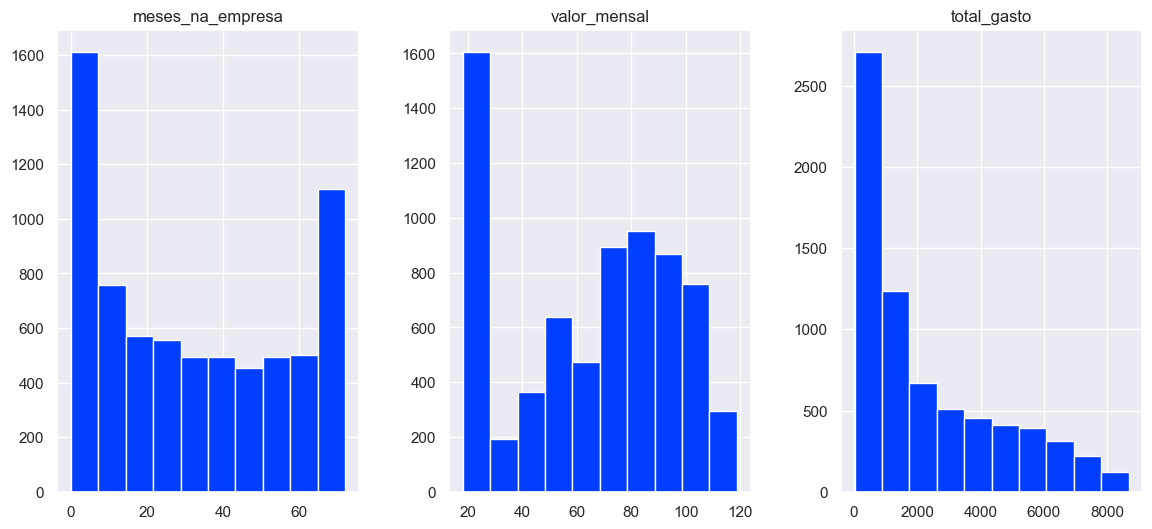

In [48]:
df_churn[colunas_numericas].hist(figsize=(14, 6),layout=(1,3));

In [49]:
df_churn['meses_na_empresa'].value_counts(bins=10).sort_index()


(-0.073, 7.2]    1612
(7.2, 14.4]       759
(14.4, 21.6]      570
(21.6, 28.8]      556
(28.8, 36.0]      545
(36.0, 43.2]      444
(43.2, 50.4]      452
(50.4, 57.6]      495
(57.6, 64.8]      501
(64.8, 72.0]     1109
Name: count, dtype: int64

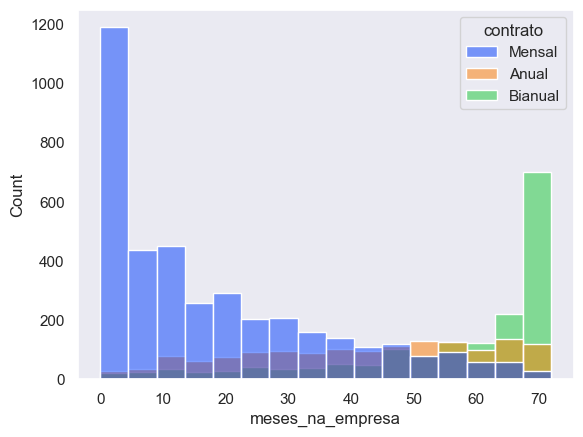

In [50]:
sns.set_theme(style='dark', palette='bright', context='notebook')

sns.histplot(x='meses_na_empresa', data=df_churn, hue='contrato');
# o que ganhamos com isso?

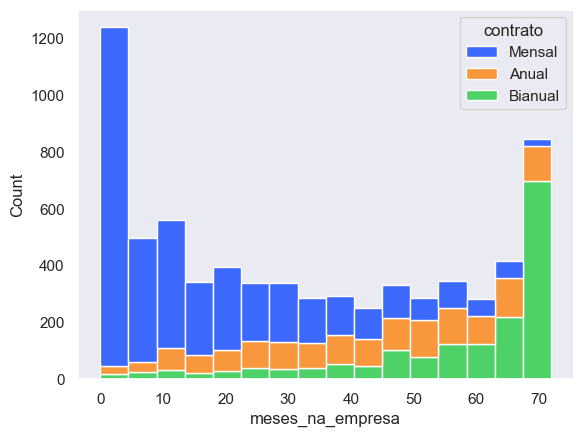

In [51]:
sns.histplot(x='meses_na_empresa', data=df_churn, hue='contrato', multiple='stack');

In [53]:
colunas_numericas

Index(['meses_na_empresa', 'valor_mensal', 'total_gasto'], dtype='object')

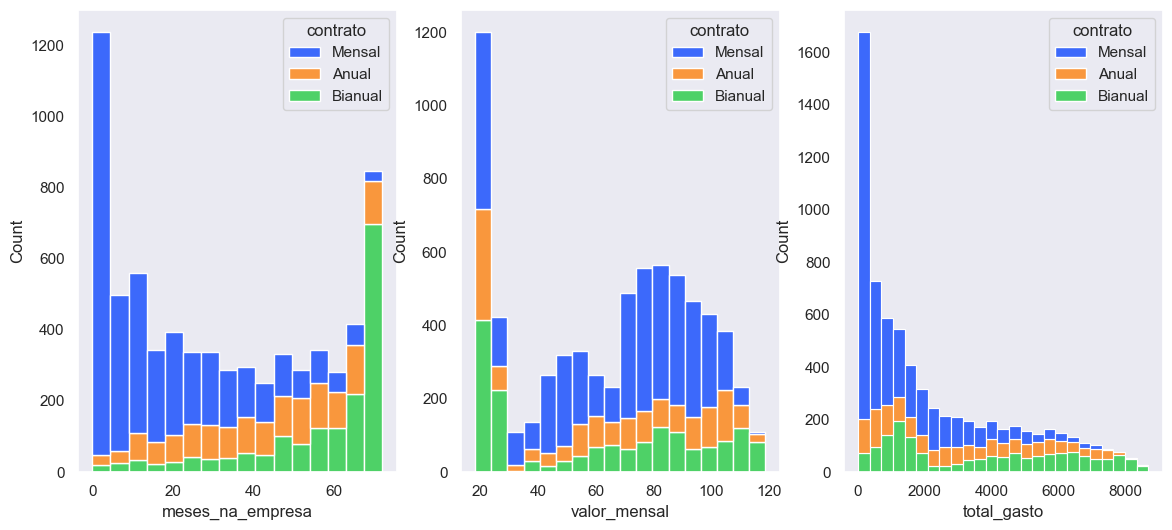

In [54]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, coluna in enumerate(colunas_numericas):
    sns.histplot(x=coluna, data=df_churn, hue='contrato', multiple='stack', ax=axs[i])

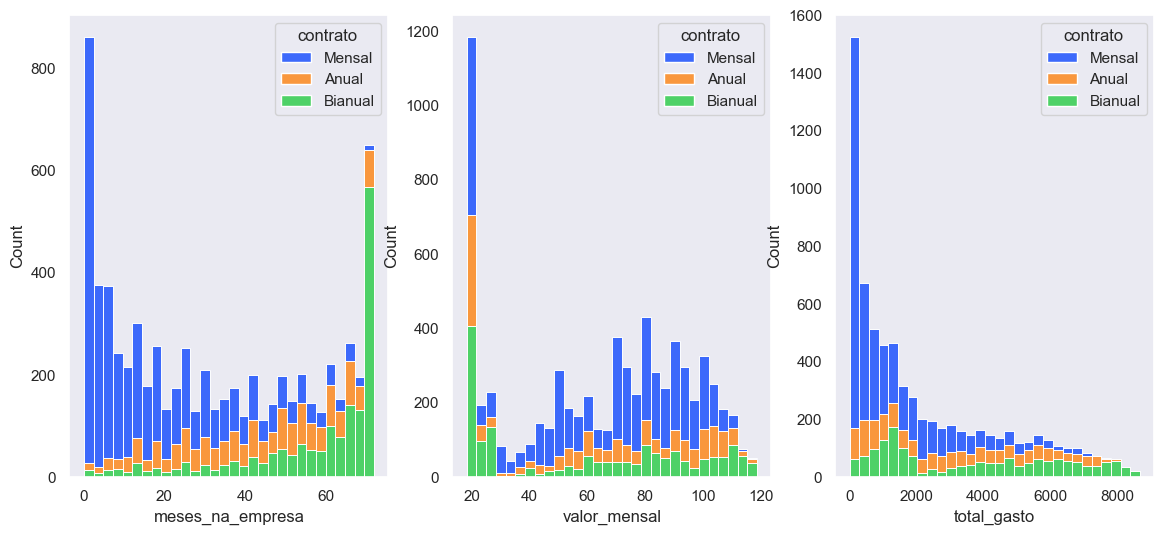

In [55]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, coluna in enumerate(colunas_numericas):
    sns.histplot(x=coluna, data=df_churn, hue='contrato', multiple='stack', ax=axs[i], bins=30)

plt.show()

# Iniciando aplicaçao de gráfico kde


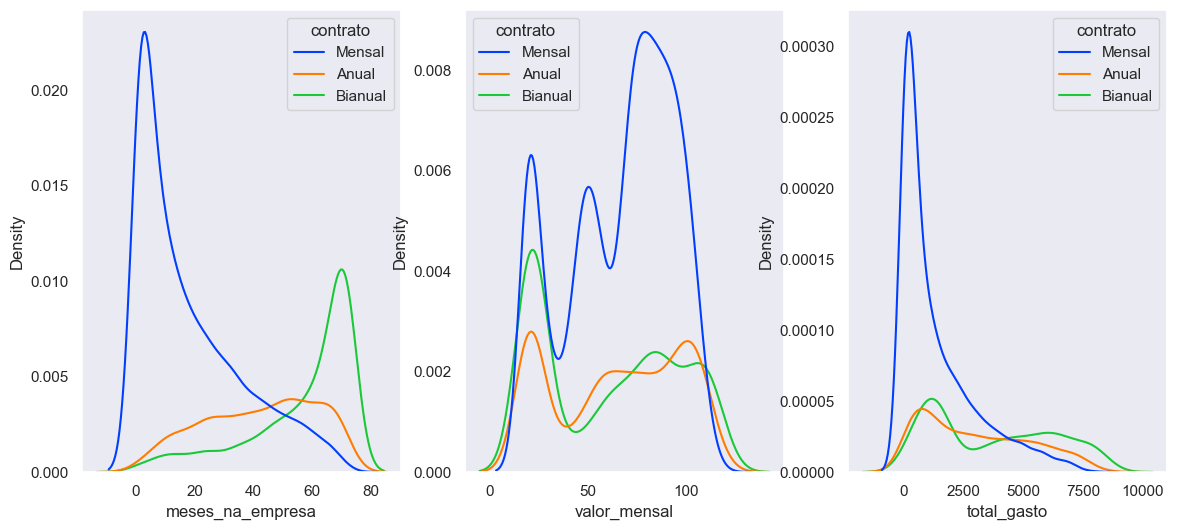

In [56]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, coluna in enumerate(colunas_numericas):
    sns.kdeplot(x=coluna, data=df_churn, hue='contrato', ax=axs[i])

plt.show()

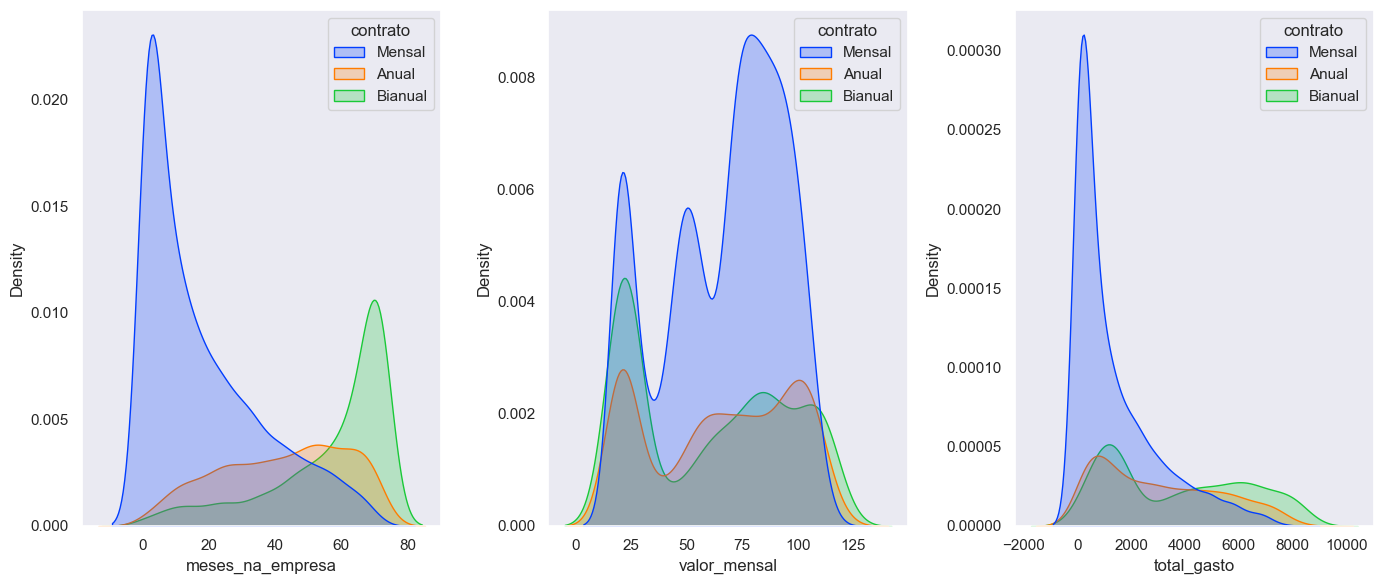

In [57]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), tight_layout=True)

for i, coluna in enumerate(colunas_numericas):
    sns.kdeplot(x=coluna, data=df_churn, hue='contrato', ax=axs[i],  fill=True)

plt.show()

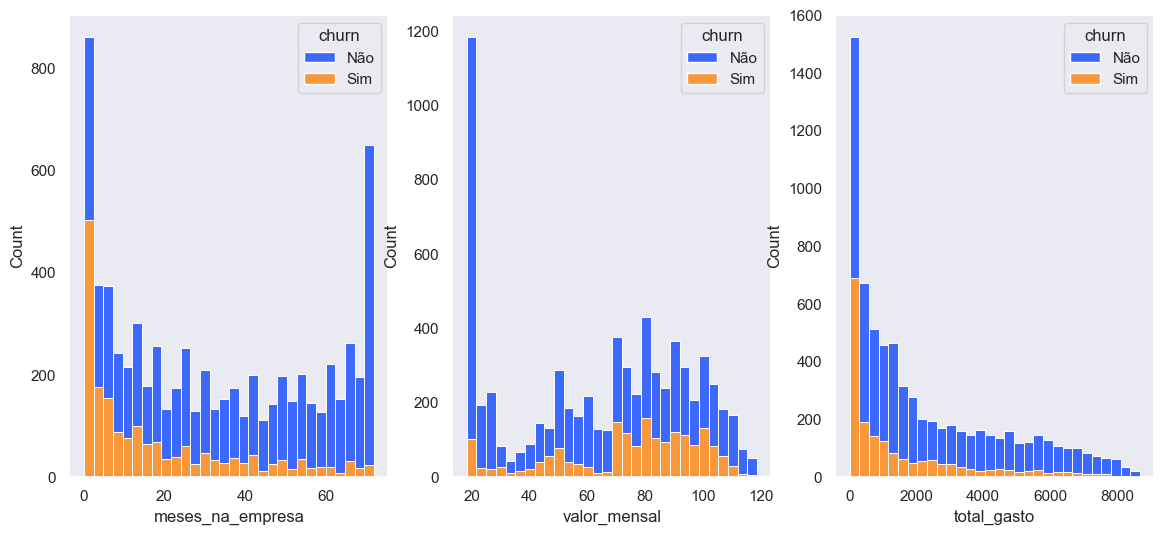

In [58]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, coluna in enumerate(colunas_numericas):
    sns.histplot(x=coluna, data=df_churn, hue='churn', multiple='stack', ax=axs[i], bins=30)

plt.show()

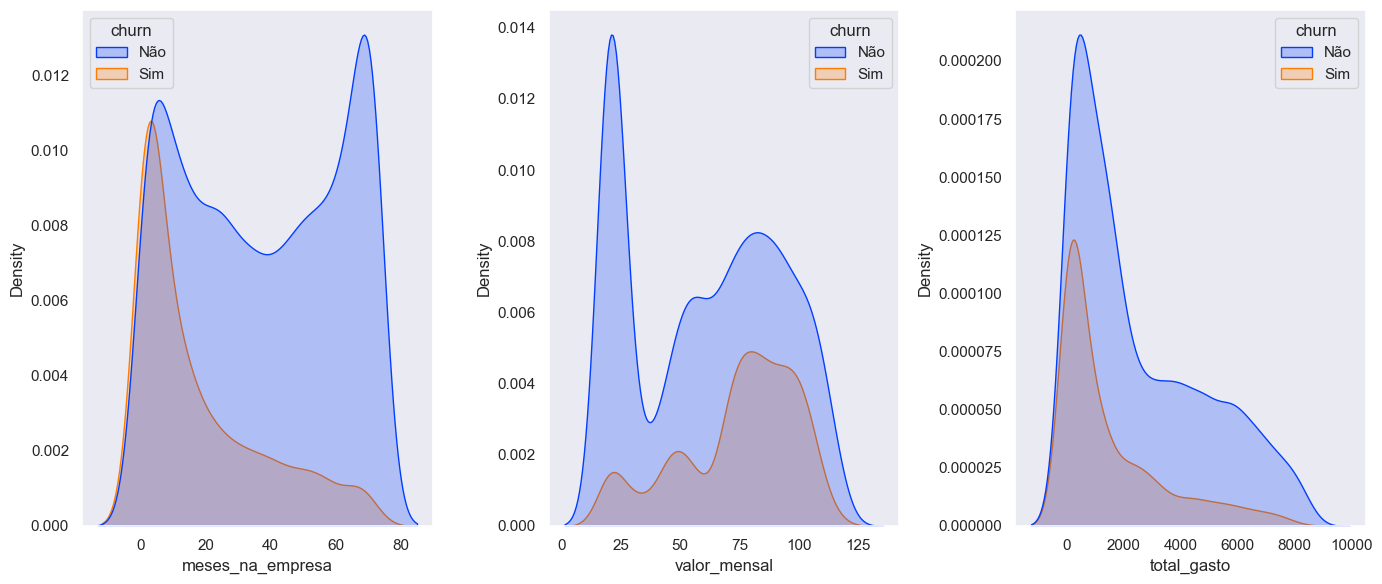

In [59]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), tight_layout=True)

for i, coluna in enumerate(colunas_numericas):
    sns.kdeplot(x=coluna, data=df_churn, hue='churn', ax=axs[i],  fill=True)

plt.show()

# Aperfeiçoando o gráfico kde

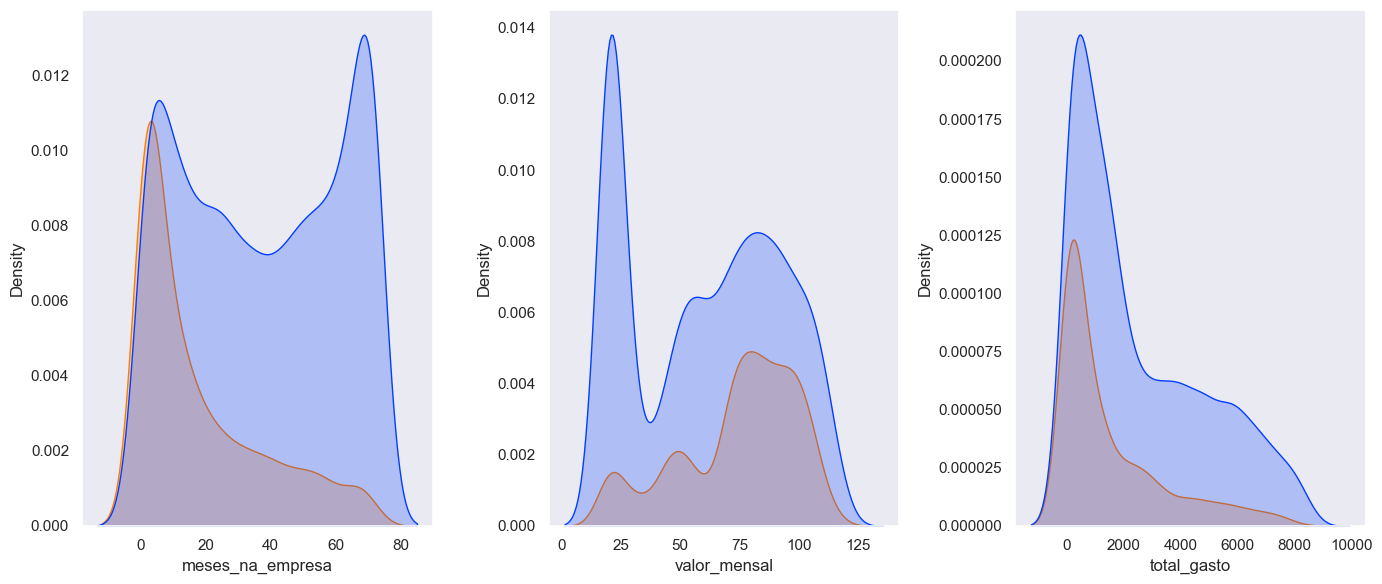

In [60]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), tight_layout=True)

for i, coluna in enumerate(colunas_numericas):
    sns.kdeplot(x=coluna, data=df_churn, hue='churn', ax=axs[i],  fill=True)
    legenda = axs[i].get_legend()
    legenda.remove()

plt.show()

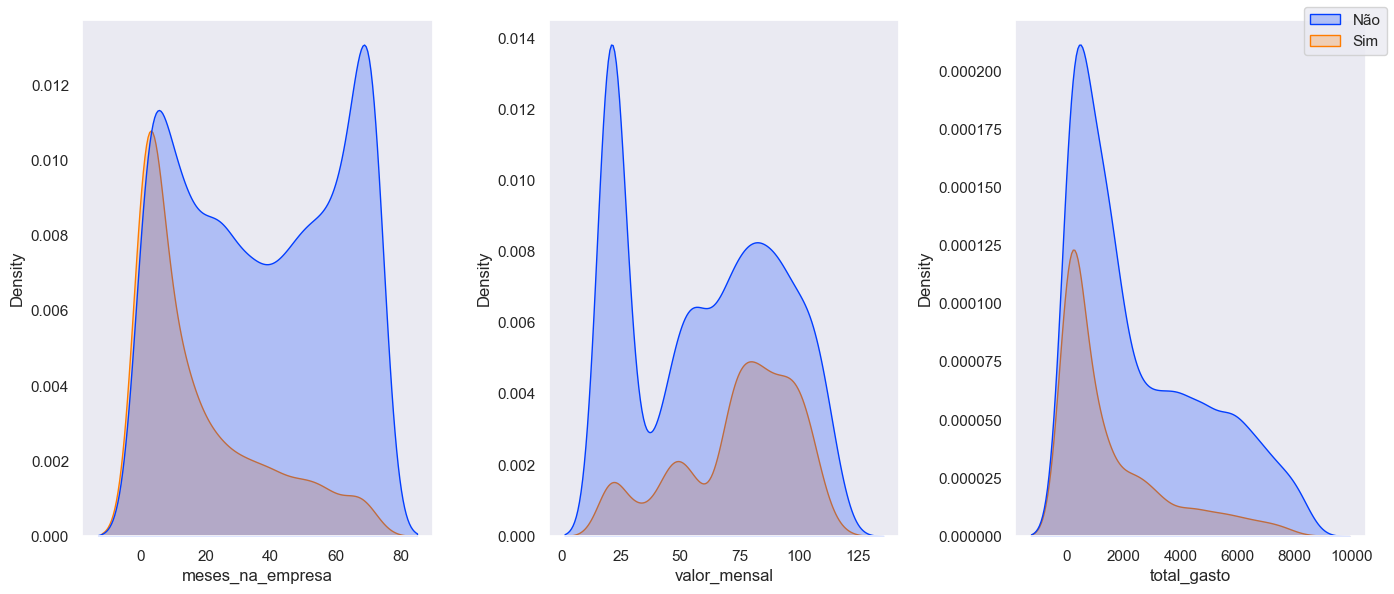

In [61]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), tight_layout=True)

for i, coluna in enumerate(colunas_numericas):
    sns.kdeplot(x=coluna, data=df_churn, hue='churn', ax=axs[i],  fill=True)
    legenda = axs[i].get_legend()
    legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos) #criou uma única caixinha a nível de figura.

plt.show()

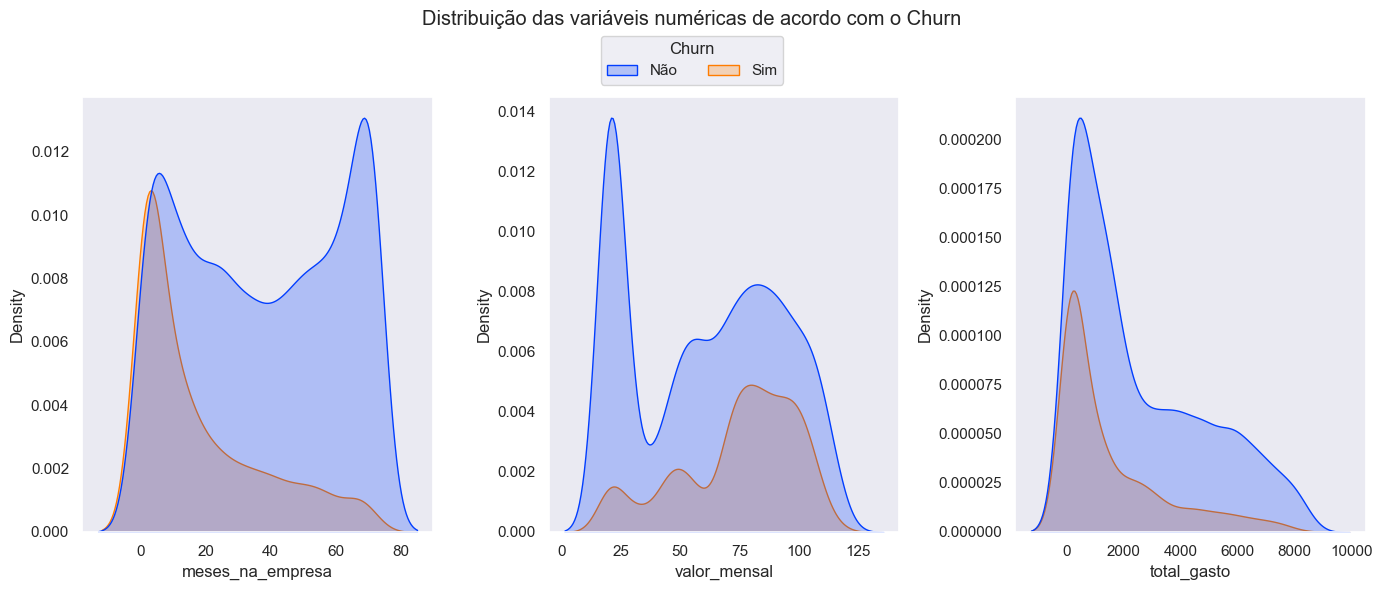

In [62]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), tight_layout=True)

for i, coluna in enumerate(colunas_numericas):
    sns.kdeplot(x=coluna, data=df_churn, hue='churn', ax=axs[i],  fill=True)
    legenda = axs[i].get_legend()
    legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos, loc='upper center', ncols=2, title='Churn', bbox_to_anchor=(0.5, 0.95)) #criou uma única caixinha a nível de figura.
fig.suptitle('Distribuição das variáveis numéricas de acordo com o Churn\n\n')

plt.show()